### *Data exploration*

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
data = pd.read_csv("global_fuel_prices_2020_2026.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [4]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['quarter'] = data['date'].dt.to_period('Q')

summary = data.groupby(['region', 'income_level', 'subsidy_level', 'year']).agg({
    'petrol_usd_liter': 'mean',
    'diesel_usd_liter': 'mean',
    'lpg_usd_liter': 'mean',
    'brent_crude_usd': 'mean',
    'tax_percentage': 'mean'
}).round(3)
summary.head()

petrol_usd_liter  diesel_usd_liter  \
region income_level subsidy_level year                                       
Africa Low          High          2020             0.356             0.322   
                                  2021             0.543             0.493   
                                  2022             0.600             0.549   
                                  2023             0.532             0.486   
                                  2024             0.608             0.555   

                                        lpg_usd_liter  brent_crude_usd  \
region income_level subsidy_level year                                   
Africa Low          High          2020          0.265           69.443   
                                  2021          0.407          106.590   
                                  2022          0.449          117.121   
                                  2023          0.398          104.426   
                                  2024          0.457          118.995   

                                        tax_percentage  
region income_level subsidy_level year                  
Africa Low          High          2020          14.112  
                                  2021          17.151  
                                  2022          16.055  
                                  2023          14.580  
                                  2024          14.360

### Key analysis directions

Use these checks and plots to get the strongest insights from the dataset. Start with overall region and country averages, then look at distributions and time trends.

In [5]:
print('Regions:', data.region.nunique(), 'Income levels:', data.income_level.nunique(), 'Subsidy levels:', data.subsidy_level.nunique())
print('Years:', data.year.min(), '-', data.year.max())
avg_by_region = data.groupby('region')[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].mean().round(3)
print('Average fuel price by region:')
print(avg_by_region)

top_petrol = data.groupby('country')['petrol_usd_liter'].mean().sort_values(ascending=False).head(10)
print('Top 10 countries by average petrol price:')
print(top_petrol)

Regions: 7 Income levels: 3 Subsidy levels: 4
Years: 2020 - 2026
Average fuel price by region:
               petrol_usd_liter  diesel_usd_liter  lpg_usd_liter
region                                                          
Africa                    1.549             1.427          1.162
Asia                      2.141             1.977          1.605
Europe                    3.702             3.518          2.776
Middle East               1.226             1.141          0.919
North America             2.064             1.892          1.548
Oceania                   3.655             3.467          2.742
South America             1.425             1.290          1.069
Top 10 countries by average petrol price:
country
Hong Kong      5.540618
Norway         4.764419
Netherlands    4.655067
Ireland        4.653841
Denmark        4.543031
Singapore      4.542700
Sweden         4.431144
Switzerland    4.386908
Belgium        4.320615
Finland        4.255153
Name: petrol_usd_liter, dtype:

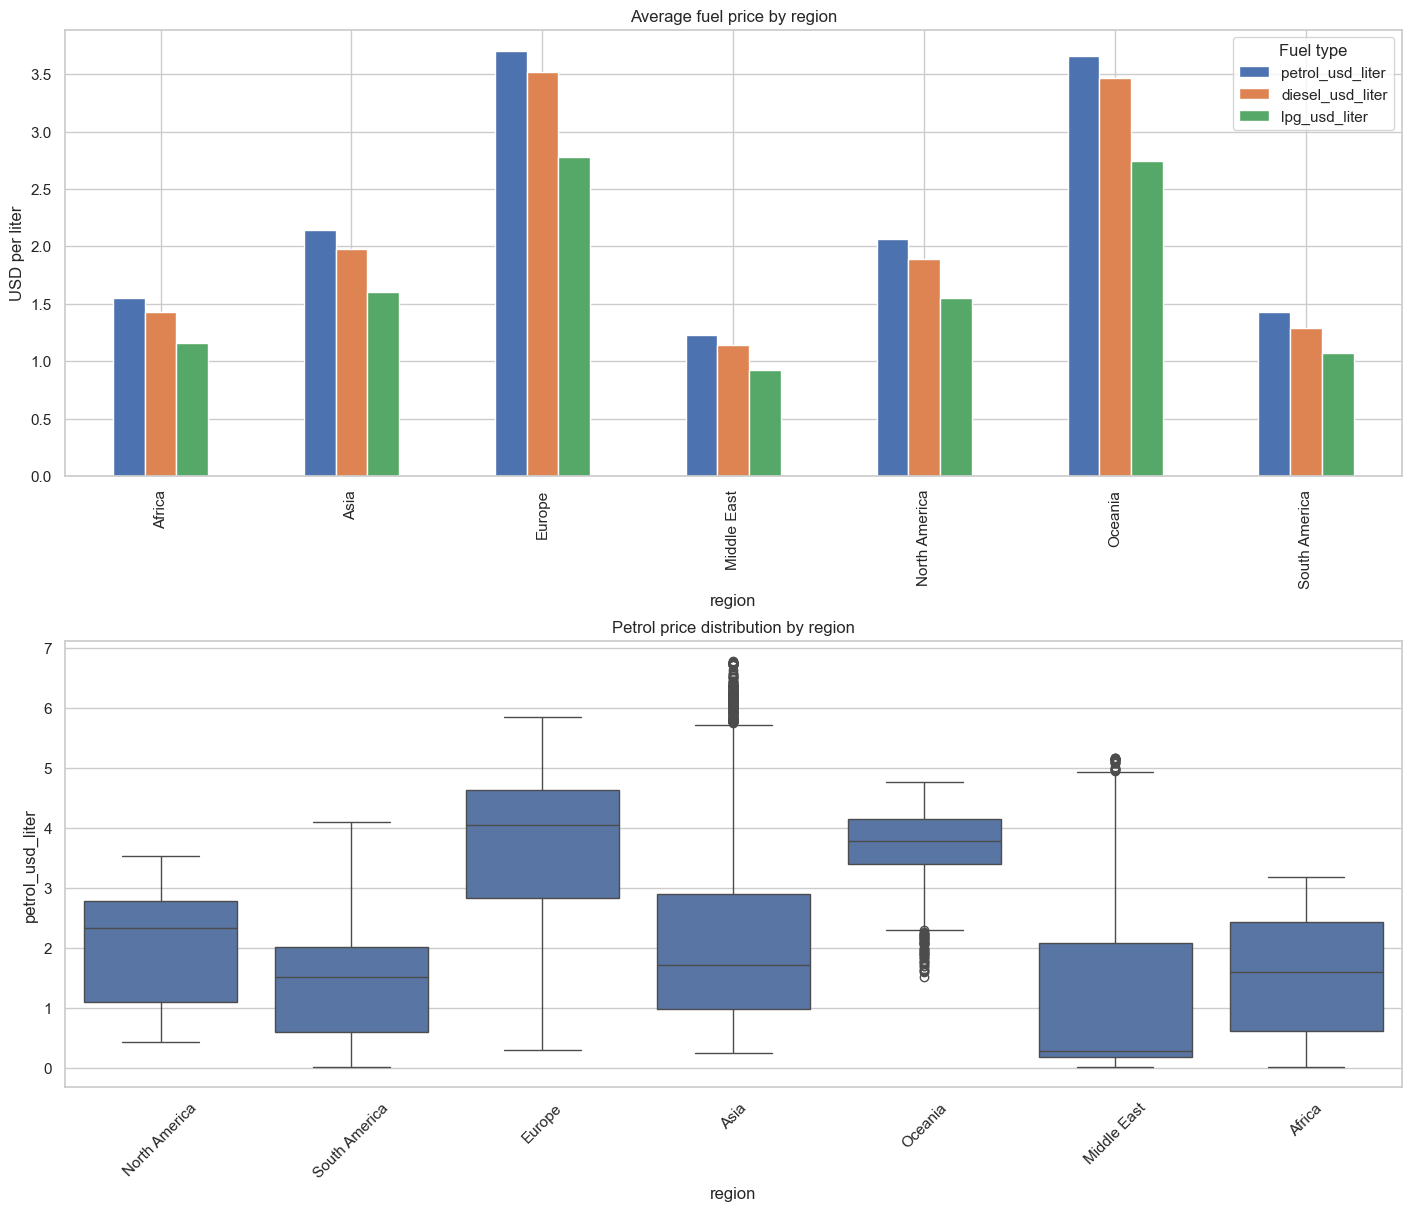

<Figure size 1200x600 with 0 Axes>

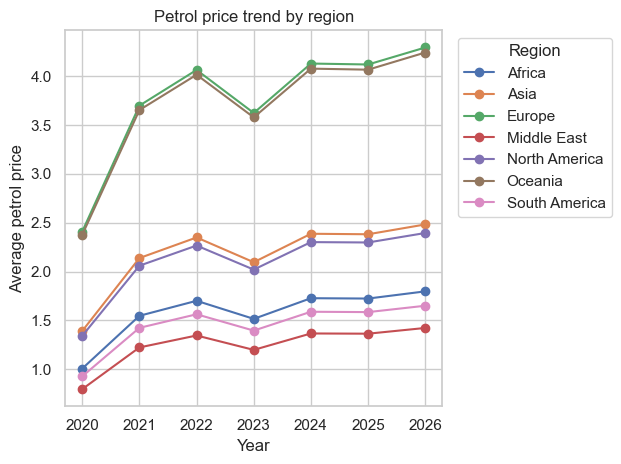

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), constrained_layout=True)
avg_by_region.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average fuel price by region')
axes[0].set_ylabel('USD per liter')
axes[0].legend(title='Fuel type')
sns.boxplot(data=data, x='region', y='petrol_usd_liter', ax=axes[1])
axes[1].set_title('Petrol price distribution by region')
axes[1].tick_params(axis='x', rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
yearly = data.groupby(['year', 'region'])['petrol_usd_liter'].mean().unstack()
yearly.plot(marker='o')
plt.title('Petrol price trend by region')
plt.ylabel('Average petrol price')
plt.xlabel('Year')
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [3]:
data.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [4]:
print(f"There are {data.country.nunique()} countries")
print(f"from {data.region.nunique()} regions")
data.region.unique()

There are 84 countries
from 7 regions


array(['North America', 'South America', 'Europe', 'Asia', 'Oceania',
       'Middle East', 'Africa'], dtype=object)

In [5]:
data.describe()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2.281915,2.133760,1.711473,106.686453,26.774468
std,1.540612,1.465058,1.155543,18.972391,17.203349
min,0.010000,0.010000,0.010000,47.970000,0.000000
25%,0.926000,0.858000,0.695000,101.140000,13.500000
50%,2.116500,1.954500,1.588000,112.270000,23.400000
75%,3.457000,3.231000,2.590000,119.410000,38.900000
max,6.779000,6.240000,5.100000,130.000000,65.000000


In [6]:
# Specified regions
asia = data[data.region == "Asia"]
asia.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
10791,2020-01-06,China,Asia,Middle,Medium,0.980,0.973,0.722,65.75,4.1
10792,2020-01-13,China,Asia,Middle,Medium,0.985,0.953,0.742,65.54,2.1
10793,2020-01-20,China,Asia,Middle,Medium,0.990,0.939,0.756,66.51,9.3
10794,2020-01-27,China,Asia,Middle,Medium,1.022,0.985,0.775,68.79,29.1
10795,2020-02-03,China,Asia,Middle,Medium,1.012,0.959,0.774,68.44,24.5


In [7]:
africa = data[data.region == "Africa"]
africa.country.unique()

array(['Egypt', 'South Africa', 'Nigeria', 'Kenya', 'Ethiopia', 'Ghana',
       'Tanzania', 'Morocco', 'Algeria', 'Libya', 'Tunisia', 'Angola',
       'Mozambique', 'Zambia', 'Zimbabwe', 'Uganda', 'Cameroon',
       'Senegal', 'Ivory Coast', 'Sudan', 'Botswana', 'Namibia', 'Rwanda'],
      dtype=object)

In [8]:
asia.income_level.value_counts()

income_level
Middle    2289
High      1635
Low       1635
Name: count, dtype: int64

In [9]:
# find the mean of each income level for deferent region
region_levels= data.groupby("region")["income_level"].value_counts()
region_levels

region         income_level
Africa         Low             5559
               Middle          1962
Asia           Middle          2289
               High            1635
               Low             1635
Europe         High            5559
               Middle          1962
Middle East    High            1635
               Middle          1308
North America  High             654
               Middle           327
Oceania        High             654
South America  Middle          1635
               High             327
               Low              327
Name: count, dtype: int64

In [10]:
data.subsidy_level.unique()

array(['Low', 'High', 'Medium', 'Very High'], dtype=object)

In [11]:
# asia.subsidy_level.unique()
africa.subsidy_level.value_counts()

subsidy_level
Low          3597
Medium       1635
Very High    1308
High          981
Name: count, dtype: int64

In [12]:
africa_mean_prices = africa.diesel_usd_liter.max()
print(africa_mean_prices)

2.991


In [13]:
mean_of_african_c = africa.groupby("country")["petrol_usd_liter"].mean().sort_values(ascending= False)
print(mean_of_african_c)

country
Zimbabwe        2.584242
South Africa    2.547450
Rwanda          2.498569
Zambia          2.497673
Mozambique      2.412584
Namibia         2.358657
Uganda          2.327927
Botswana        2.263817
Kenya           2.239523
Tanzania        2.153636
Ghana           2.067076
Morocco         1.693425
Senegal         1.477924
Ethiopia        1.413000
Ivory Coast     1.408933
Cameroon        1.344547
Tunisia         0.676960
Sudan           0.568431
Angola          0.521872
Nigeria         0.213156
Egypt           0.171792
Algeria         0.140517
Libya           0.056382
Name: petrol_usd_liter, dtype: float64


In [13]:
africa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7521 entries, 19947 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              7521 non-null   object 
 1   country           7521 non-null   object 
 2   region            7521 non-null   object 
 3   income_level      7521 non-null   object 
 4   subsidy_level     7521 non-null   object 
 5   petrol_usd_liter  7521 non-null   float64
 6   diesel_usd_liter  7521 non-null   float64
 7   lpg_usd_liter     7521 non-null   float64
 8   brent_crude_usd   7521 non-null   float64
 9   tax_percentage    7521 non-null   float64
dtypes: float64(5), object(5)
memory usage: 646.3+ KB


In [14]:
#practice agg 
africa_countries_avg = africa.groupby("country").agg({"petrol_usd_liter": "mean", 
                                               "diesel_usd_liter": "mean",
                                               "lpg_usd_liter": "mean",
                                              "brent_crude_usd": "mean" }).sort_values(by= "petrol_usd_liter",ascending= False)
print(africa_countries_avg)

              petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  \
country                                                           
Zimbabwe              2.584242          2.412064       1.938248   
South Africa          2.547450          2.359220       1.911034   
Rwanda                2.498569          2.328691       1.873933   
Zambia                2.497673          2.326407       1.873226   
Mozambique            2.412584          2.240661       1.809220   
Namibia               2.358657          2.170798       1.767624   
Uganda                2.327927          2.152067       1.745575   
Botswana              2.263817          2.076645       1.696813   
Kenya                 2.239523          2.067040       1.679092   
Tanzania              2.153636          1.980905       1.615153   
Ghana                 2.067076          1.897003       1.551278   
Morocco               1.693425          1.548217       1.271725   
Senegal               1.477924          1.344982       1.10821

In [14]:
asia_countries_avg = asia.groupby("country").agg({"petrol_usd_liter": "mean", 
                                               "diesel_usd_liter": "mean",
                                               "lpg_usd_liter": "mean",
                                              "brent_crude_usd": "mean" }).sort_values(by= "petrol_usd_liter",ascending= False)
print(asia_countries_avg[:6])

             petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  \
country                                                          
Hong Kong            5.540618          5.097009       4.155303   
Singapore            4.542700          4.210722       3.407009   
South Korea          3.655624          3.435183       2.742713   
Japan                3.435266          3.213911       2.575740   
Taiwan               2.880266          2.659410       2.160055   
Philippines          2.360171          2.170902       1.770795   

             brent_crude_usd  
country                       
Hong Kong         106.686453  
Singapore         106.686453  
South Korea       106.686453  
Japan             106.686453  
Taiwan            106.686453  
Philippines       106.686453  


In [15]:
#Africa income levels 
africa_income = africa.income_level.value_counts().sort_values(ascending=False)
#Asia income levels
asia_income = asia.income_level.value_counts().sort_values(ascending=False)
print(f"Africa \n{africa_income}\nAsai \n{asia_income}")

Africa 
income_level
Low       5559
Middle    1962
Name: count, dtype: int64
Asai 
income_level
Middle    2289
High      1635
Low       1635
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

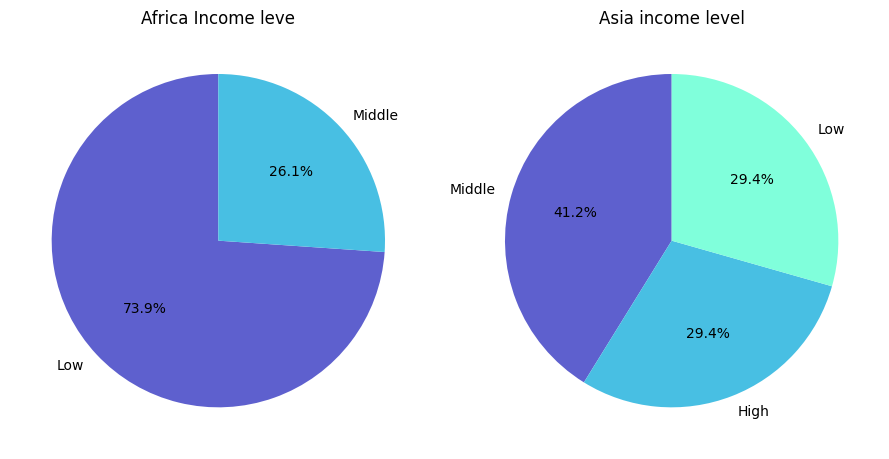

In [35]:
# Create pie charts 
mcolors = ['#5E60CE', '#48BFE3', '#80FFDB','#6930C3']

fig, axes = plt.subplots(ncols= 2, nrows = 1, figsize = (9,6))

africa_income.plot.pie(colors = mcolors, autopct = "%1.1f%%", startangle = 90, ax = axes[0], ylabel = '', title = "Africa Income leve")
asia_income.plot.pie(colors = mcolors, autopct = "%1.1f%%", startangle = 90, ax = axes[1], ylabel = '', title = "Asia income level")
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

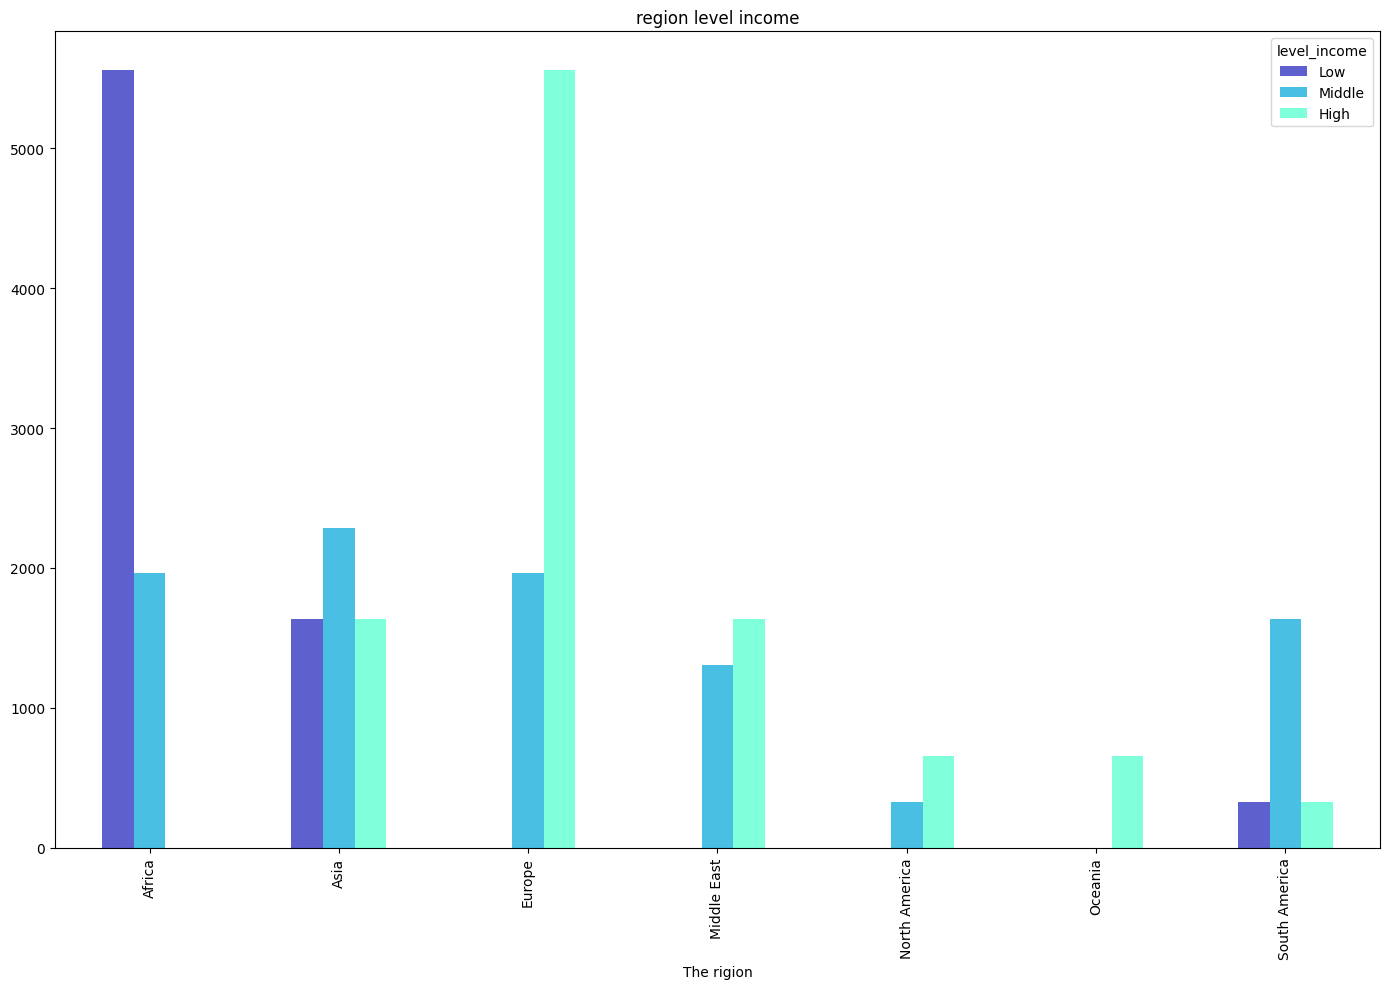

In [30]:
# Show the total level income of each region
mcolors = ['#5E60CE', '#48BFE3', '#80FFDB']
level_income_of_region = data.groupby("region")["income_level"].value_counts().unstack()
levels = level_income_of_region [["Low","Middle","High"]]

# apply the plot
bar_chart = levels.plot(kind= "bar", figsize = (14,10), title = "region level income", color = mcolors)
plt.xlabel("The rigion")
plt.legend(title="level_income")
plt.tight_layout()
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

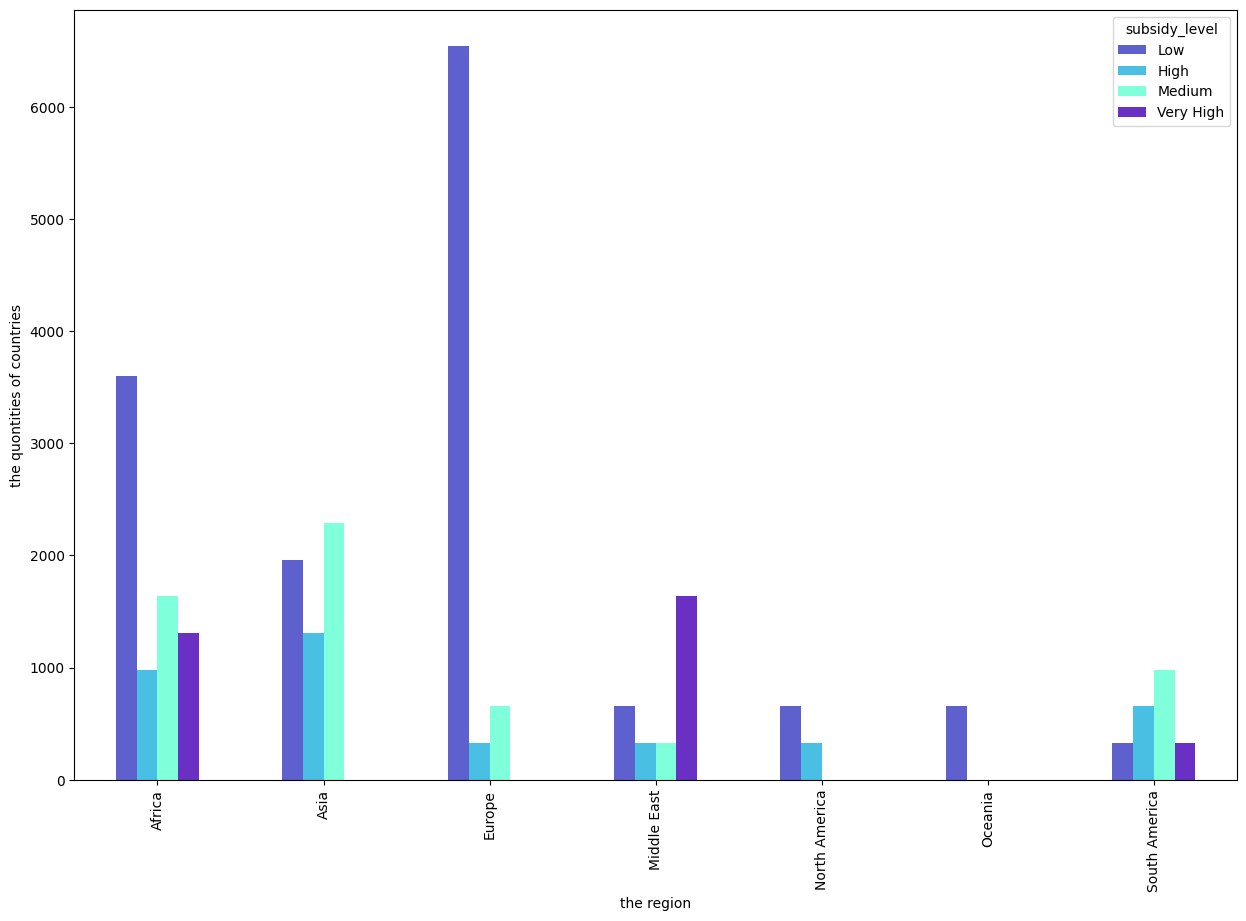

In [36]:
# show the regions subsidy level 
level_subsidy = data.groupby("region")["subsidy_level"].value_counts().unstack()

level = level_subsidy [['Low', 'High', 'Medium', 'Very High']]
bar_chart2 = level.plot(kind= "bar", figsize= (15,10), color = mcolors)
plt.xlabel("the region")
plt.ylabel("the quontities of countries")

plt.legend(title= "subsidy_level")
plt.show

In [33]:
data

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4
...,...,...,...,...,...,...,...,...,...,...
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.00,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.00,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.00,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.00,43.7
